In [1]:
# Importación de librerías necesarias para el análisis y visualización de datos, así como para la aplicación de PCA y t-SNE.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Configuración visual  de Seaborn para gráficos más atractivos
sns.set_theme(style="whitegrid")

In [2]:
# Carga y análisis exploratorio inicial (Dataset Clínico Simulado) 
# Simulamos 500 pacientes, 100 variables y 2 clases (Sano vs Enfermedad)
X, y = make_classification(n_samples=500, n_features=100, n_informative=15, 
                           n_redundant=20, n_classes=2, random_state=42, 
                           weights=[0.6, 0.4]) # Clases ligeramente desbalanceadas

df_clinico = pd.DataFrame(X, columns=[f'Feature_{i}' for i in range(1, 101)])
df_clinico['Diagnostico'] = y

print("Dimensiones del dataset:", df_clinico.shape)
display(df_clinico.head()) 

Dimensiones del dataset: (500, 101)


,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,Feature_8,Feature_9,Feature_10,...,Feature_92,Feature_93,Feature_94,Feature_95,Feature_96,Feature_97,Feature_98,Feature_99,Feature_100,Diagnostico
0,0.107186,0.544613,0.595157,0.998305,0.354818,-0.676316,0.682653,0.912602,-0.292516,5.910197,...,0.128099,-5.114039,-3.943302,0.330382,0.667383,-0.043546,4.468151,-0.985056,0.117844,0
1,-0.977072,0.841041,0.073887,-1.242872,1.274064,2.177293,-0.912679,0.714550,0.574386,0.054251,...,-1.710175,-7.568360,-1.018626,1.837923,0.259596,0.459575,1.423810,-1.943556,0.133942,0
2,-0.968129,-1.991140,0.645798,-2.001706,-2.491161,-0.223667,1.895507,0.087357,-0.361230,-3.061480,...,-0.527701,-6.817564,0.535561,-1.709018,2.572752,0.099988,-1.768439,2.133747,0.245292,0
3,0.456642,0.630665,0.816985,0.328659,-0.383960,0.673944,-0.593699,-1.888619,-0.043040,-5.016512,...,-1.333967,-3.400275,2.370558,-0.014473,1.170996,0.117950,-1.315792,4.401822,0.708112,1
4,-0.958804,-0.298600,-1.239304,1.308918,1.376718,0.268347,1.534367,-1.053173,-1.221575,-1.417007,...,0.385205,-1.370270,2.807226,1.741988,-1.285186,-1.700065,0.141350,-0.074239,-0.769314,0


In [3]:
# Aplicación de StandardScaler
X_data = df_clinico.drop('Diagnostico', axis=1)
y_label = df_clinico['Diagnostico']

# Escalamos los datos (es vital para PCA y t-SNE)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_data)

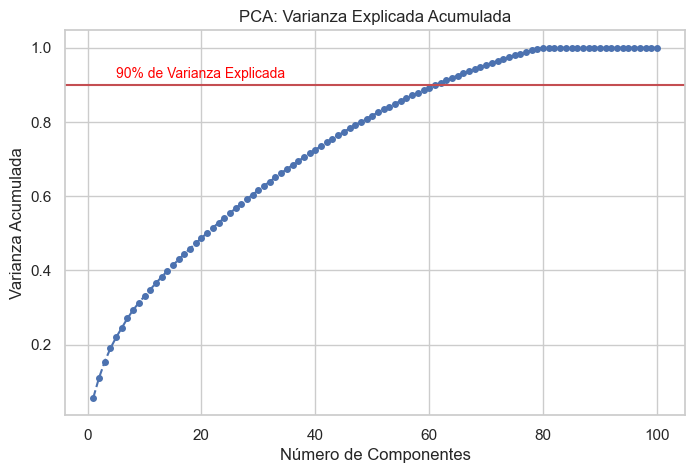

Componentes necesarios para retener el 90% de la información: 62


In [4]:
# Aplicación de PCA y Varianza Explicada para determinar el número óptimo de componentes a retener
pca = PCA()
X_pca_full = pca.fit_transform(X_scaled)

# Gráfico de varianza explicada acumulada para visualizar el porcentaje de información retenida por cada número de componentes
varianza_acumulada = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 101), varianza_acumulada, marker='o', linestyle='--', markersize=4)
plt.axhline(y=0.90, color='r', linestyle='-') # Línea de retención del 90%
plt.text(5, 0.92, '90% de Varianza Explicada', color = 'red', fontsize=10)
plt.title('PCA: Varianza Explicada Acumulada')
plt.xlabel('Número de Componentes')
plt.ylabel('Varianza Acumulada')
plt.show()

# Extraer componentes óptimos (ej. los necesarios para el 90% de la varianza) 
n_optimo = np.argmax(varianza_acumulada >= 0.90) + 1
print(f"Componentes necesarios para retener el 90% de la información: {n_optimo}")

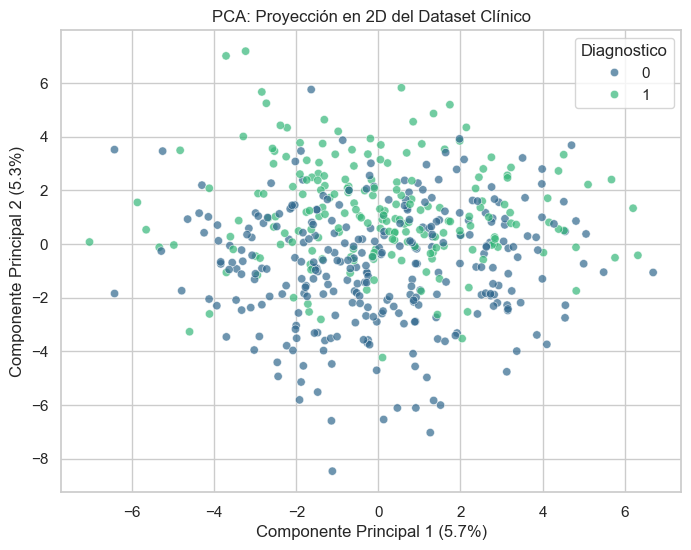

In [5]:
# Visualización de PCA en 2D con los componentes principales seleccionados
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca_2d[:, 0], y=X_pca_2d[:, 1], hue=y_label, palette='viridis', alpha=0.7)
plt.title('PCA: Proyección en 2D del Dataset Clínico')
plt.xlabel(f'Componente Principal 1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'Componente Principal 2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)')
plt.show()

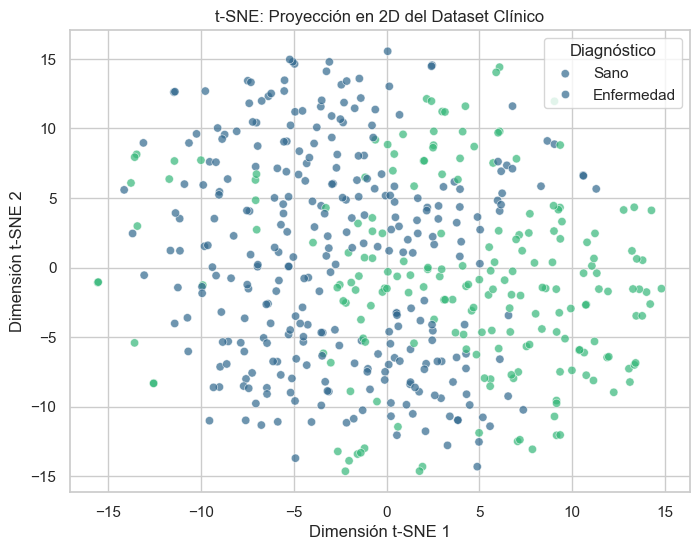

In [6]:
# Aplicación de t-SNE y Visualización en 2D
tsne = TSNE(
    n_components=2, 
    perplexity=30, 
    learning_rate='auto', # 'auto' es recomendado en versiones nuevas para evitar divergencia
    init='pca',           # Ayuda a que sea más estable y rápido
    random_state=42
)

# Ejecutamos fit_transform
X_tsne_2d = tsne.fit_transform(X_scaled)

# Visualización
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_tsne_2d[:, 0], y=X_tsne_2d[:, 1], hue=y_label, palette='viridis', alpha=0.7)
plt.title('t-SNE: Proyección en 2D del Dataset Clínico')
plt.xlabel('Dimensión t-SNE 1')
plt.ylabel('Dimensión t-SNE 2')
plt.legend(title='Diagnóstico', labels=['Sano', 'Enfermedad'])
plt.show()